**NAME - RUCHITA PANKAJ BODKE**\
**PRN - 202401110022**\
**BRANCH - CSE-AIML**\
**BATCH - A2**\
**COURSE - GENERATIVE AI**

Practical No. 02: Text Classification using Embedding Layer and LSTM

**Aim** -
To build a multiclass text classification model using an Embedding layer and LSTM (Long Short-Term Memory) network and evaluate its performance using appropriate classification metrics.


---



**Problem Statement** -
Build a deep learning model that classifies news articles into one of multiple predefined categories. The model uses an Embedding layer to represent words as dense vectors and an LSTM layer to learn sequential relationships between words.

Dataset Used: Reuters Newswire Dataset
The Reuters Newswire Classification Dataset available through Keras is used for this practical.

| Property | Details |
|---|---|
| Dataset | Reuters Newswire Classification |
| Source | Keras built-in dataset |
| Total newswires | 11,228 |
| Number of classes | 46 |
| Task | Multiclass classification |
| Input | Newswire text |
| Output | Topic/category |
| Data format | Integer-encoded word sequences |

1. Import Required Libraries

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import reuters
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [12]:
# ==========================================
# 1. Load Reuters Dataset
# ==========================================

vocab_size = 10000
num_classes = 46
max_length = 300

(x, y), (x_test, y_test) = reuters.load_data(
    num_words=vocab_size
)

print("Total training samples:", len(x))
print("Testing samples:", len(x_test))
print("Number of classes:", num_classes)

Total training samples: 8982
Testing samples: 2246
Number of classes: 46


In [13]:
# ==========================================
# 2. Padding
# ==========================================

x = pad_sequences(
    x,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

x_test = pad_sequences(
    x_test,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("Training shape:", x.shape)
print("Testing shape:", x_test.shape)

Training shape: (8982, 300)
Testing shape: (2246, 300)


In [14]:
# ==========================================
# 3. Stratified Train-Validation Split
# ==========================================

x_train, x_val, y_train, y_val = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(x_train))
print("Validation samples:", len(x_val))

Training samples: 7185
Validation samples: 1797


In [15]:
# ==========================================
# 4. Calculate Class Weights
# ==========================================

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(
    zip(classes, weights)
)


In [31]:
model = Sequential([
    Embedding(10000, 128),

    Bidirectional(
        LSTM(
            128,
            dropout=0.2,
            recurrent_dropout=0.2
        )
    ),

    Dropout(0.4),

    Dense(64, activation='relu'),

    Dropout(0.3),

    Dense(46, activation='softmax')
])

In [32]:
# ==========================================
# 6. Compile Model
# ==========================================

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:
# ==========================================
# 7. Callbacks
# ==========================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [34]:
# ==========================================
# 8. Train Model
# ==========================================

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.4775 - loss: 2.1808 - val_accuracy: 0.5899 - val_loss: 1.6293 - learning_rate: 0.0010
Epoch 2/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 180s 2s/step - accuracy: 0.5942 - loss: 1.6466 - val_accuracy: 0.6149 - val_loss: 1.5289 - learning_rate: 0.0010
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 216s 2s/step - accuracy: 0.6458 - loss: 1.4572 - val_accuracy: 0.6600 - val_loss: 1.3984 - learning_rate: 0.0010
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 186s 2s/step - accuracy: 0.6868 - loss: 1.2794 - val_accuracy: 0.6767 - val_loss: 1.3047 - learning_rate: 0.0010
Epoch 5/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - accuracy: 0.7137 - loss: 1.1473 - val_accuracy: 0.6878 - val_loss: 1.2889 - learning_rate: 0.0010
Epoch 6/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 215s 2s/step - accuracy: 0.7445 - loss: 1.0067 - val_accuracy: 0.7184 - val_loss: 1.1989 - learning_rate: 0.0010
Epoch 7/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 0.7724 - loss: 0.

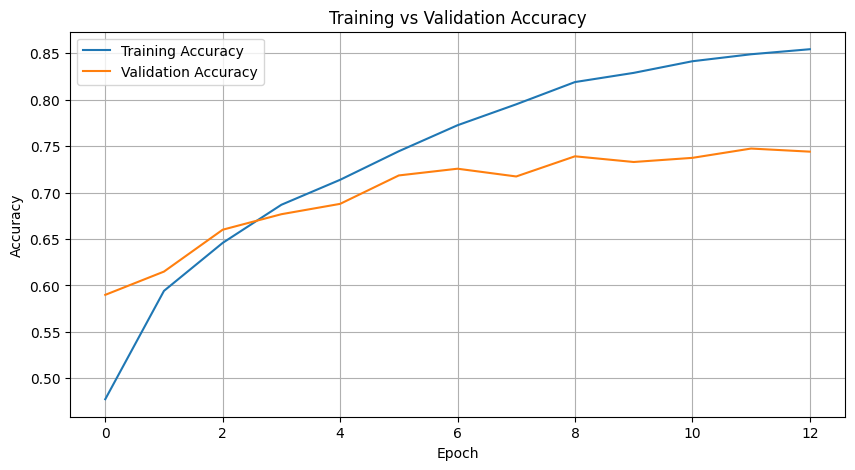

In [35]:
# Plot 1 — Accuracy

plt.figure(figsize=(10, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

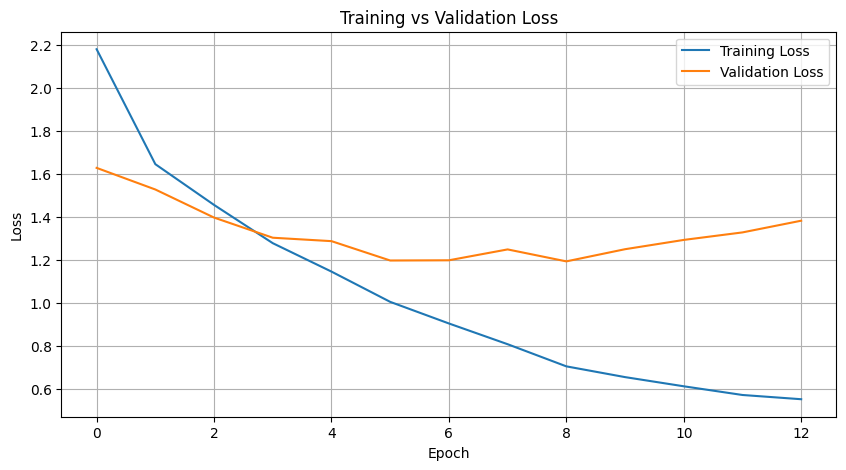

In [36]:
# Plot 2 — Loss

plt.figure(figsize=(10, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()

plt.show()

In [37]:
# Evaluate the Model

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 1.2442455291748047
Test Accuracy: 0.7226179838180542


In [38]:
# Predictions
y_probability = model.predict(x_test)

y_pred = np.argmax(
    y_probability,
    axis=1
)

# Metrics
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)

print("\nFinal Metrics")
print("-------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

71/71 ━━━━━━━━━━━━━━━━━━━━ 19s 249ms/step

Final Metrics
-------------------------
Accuracy : 0.7226179875333927
Precision: 0.6788664702459387
Recall   : 0.7226179875333927
F1 Score : 0.6971771185676029


In [39]:
# Classification Report

print("\nClassification Report")
print("-------------------------")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


Classification Report
-------------------------
              precision    recall  f1-score   support

           0       0.18      0.50      0.27        12
           1       0.65      0.72      0.68       105
           2       0.34      0.55      0.42        20
           3       0.91      0.94      0.92       813
           4       0.83      0.84      0.83       474
           5       0.00      0.00      0.00         5
           6       0.33      0.14      0.20        14
           7       0.00      0.00      0.00         3
           8       0.42      0.47      0.44        38
           9       0.51      0.76      0.61        25
          10       0.49      0.67      0.56        30
          11       0.46      0.75      0.57        83
          12       0.00      0.00      0.00        13
          13       0.20      0.24      0.22        37
          14       0.00      0.00      0.00         2
          15       0.00      0.00      0.00         9
          16       0.58      0.7

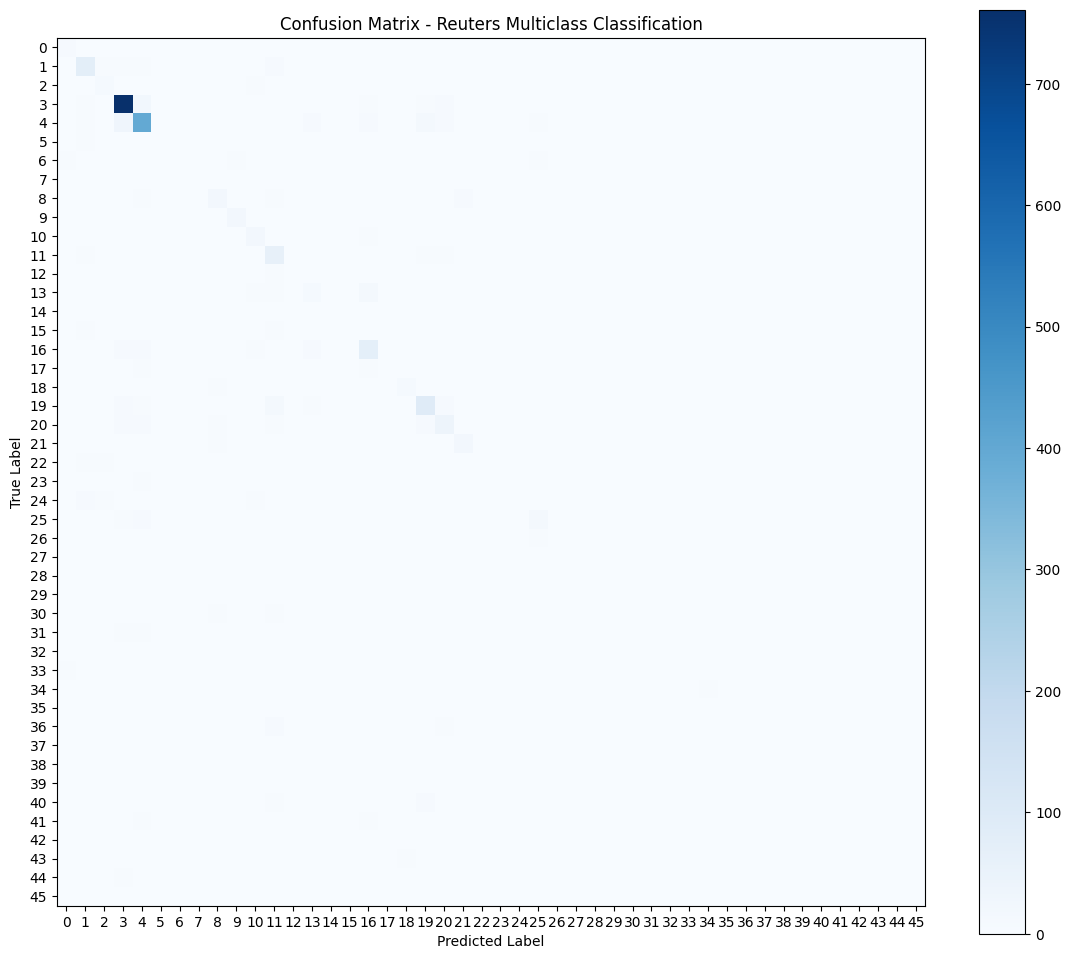

In [40]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(14, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(
    ax=ax,
    cmap='Blues',
    include_values=False
)

plt.title("Confusion Matrix - Reuters Multiclass Classification")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()